In [1]:
here::i_am("rna_atac/differential/ATAC.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

addArchRThreads(24)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()
# in dir
args$indir = file.path(io$basedir, 'results/rna_atac/differential/')

# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# Define search distance
args$dist = 150000

In [9]:
# Load differential genes
DEGs = fread(sprintf('%s/expression/DEGs_edgeR_pb.txt.gz', args$indir)) %>%
    .[,sig:=ifelse(abs(logFC)>0.75 & padj_fdr < 0.05, TRUE, FALSE)] %>%
    .[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1') ]
# Load differential peaks
DARs = fread(sprintf('%s/Accessibility/DARs_edgeR_pb.txt.gz', args$indir)) %>%
    .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr < 0.1, TRUE, FALSE)]

# Load ArchR
ArchRProject <- loadArchRProject(args$archr_directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [10]:
# Retrieve gene annotation
geneAnnotation = ArchRProject@geneAnnotation$genes

# Resctrict to differential genes & add search region
geneAnnotation_filt = geneAnnotation[geneAnnotation$symbol %in% unique(DEGs[sig==TRUE, gene])]
geneAnnotation_filt = geneAnnotation_filt + args$dist

In [11]:
# keep differential DARs & convert to GRanges
DARs_filt = DARs[sig==TRUE] %>% 
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
            .[, start:=as.numeric(str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1))] %>%
            .[, end:=as.numeric(str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2))]
DARs_filt.gr = makeGRangesFromDataFrame(DARs_filt) # [,c('chr', 'start', 'end')]
DARs_filt.gr$celltype = DARs_filt$celltype
DARs_filt.gr$logFC = DARs_filt$logFC

In [12]:
# Find overlap
DARs_DEGs_overlap = findOverlaps(geneAnnotation_filt, DARs_filt.gr)
DEG_hits = DARs_filt.gr[subjectHits(DARs_DEGs_overlap)]
DEG_hits$symbol = geneAnnotation_filt[queryHits(DARs_DEGs_overlap)]$symbol
DEG_hits$peak = paste0(DEG_hits@seqnames, ":", DEG_hits@ranges@start, '-', DEG_hits@ranges@start+600)

In [13]:
DEG_hits

GRanges object with 9659 ranges and 4 metadata columns:
         seqnames              ranges strand |     celltype     logFC
            <Rle>           <IRanges>  <Rle> |  <character> <numeric>
     [1]     chr1     5108508-5109108      * |           HE     1.519
     [2]     chr1     5108508-5109108      * |   Mesenchyme     0.703
     [3]     chr1     5082779-5083379      * |    Allantois     0.578
     [4]     chr1     5017783-5018383      * |    Allantois     0.550
     [5]     chr1     5103065-5103665      * | HE_Precursor     1.304
     ...      ...                 ...    ... .          ...       ...
  [9655]     chrX 166328149-166328749      * | HE_Precursor     0.748
  [9656]     chrX 166479463-166480063      * |  Endothelium    -0.620
  [9657]     chrX 167101819-167102419      * |  Endothelium     0.689
  [9658]     chrX 168672343-168672943      * |    Allantois    -0.567
  [9659]     chrX 169036292-169036892      * |  Endothelium    -0.615
              symbol              

In [14]:
DEGDAR = as.data.table(DEG_hits) %>%
    setnames('logFC', 'ATAC_LogFC') %>%
    setnames('symbol', 'gene') %>%
    merge(., DEGs, by=c('gene', 'celltype'))
head(DEGDAR)

gene,celltype,seqnames,start,end,width,strand,ATAC_LogFC,peak,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,sig
<chr>,<chr>,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Abcc5,Allantois,chr16,20517818,20518418,601,*,-0.528,chr16:20517818-20518418,-0.099,1.04e-01,6.21,6.05,0.58,0.56,FALSE
Abcc5,Early_Mes_EOd,chr16,20390217,20390817,601,*,-0.512,chr16:20390217-20390817,-0.037,6.46e-01,5.92,5.91,0.45,0.57,FALSE
Abcc5,Endothelium,chr16,20374075,20374675,601,*,0.650,chr16:20374075-20374675,-0.894,1.06e-08,6.63,5.73,0.68,0.56,TRUE
Abcc5,HE,chr16,20390217,20390817,601,*,-0.581,chr16:20390217-20390817,-0.014,8.51e-01,5.97,5.93,0.56,0.59,FALSE
Abcc5,HE_Precursor,chr16,20390217,20390817,601,*,-0.732,chr16:20390217-20390817,0.006,9.72e-01,5.67,5.68,0.44,0.58,FALSE
Abcc5,HE_Precursor,chr16,20374075,20374675,601,*,0.643,chr16:20374075-20374675,0.006,9.72e-01,5.67,5.68,0.44,0.58,FALSE


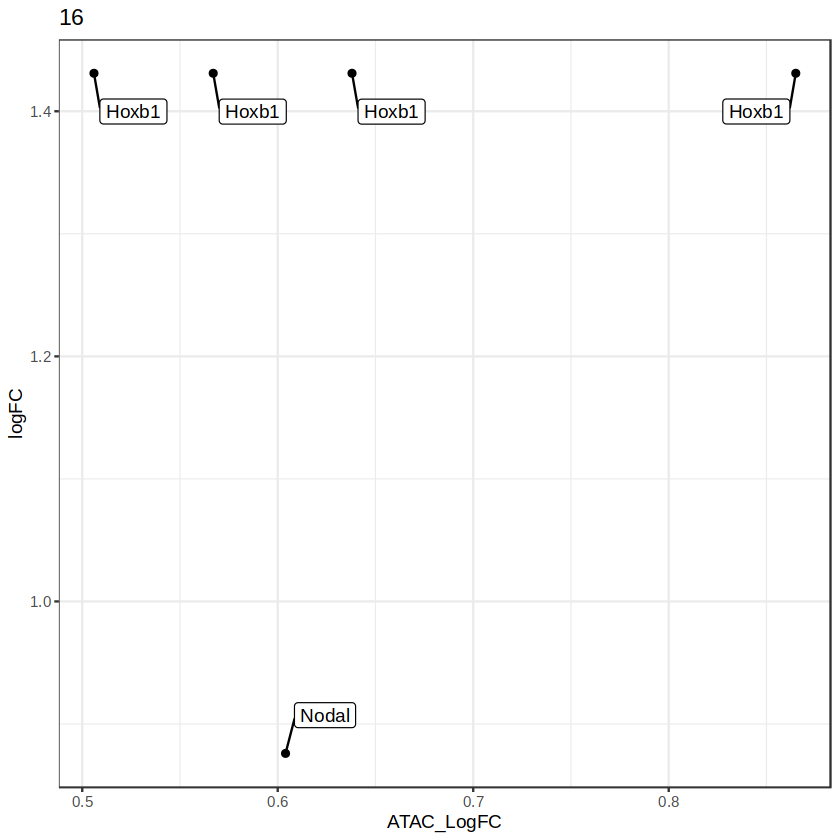

In [22]:
ggplot(DEGDAR[!is.na(logFC) & celltype=='Early_Mes_EOi' & sig==TRUE], aes(ATAC_LogFC, logFC, label=gene)) + 
    geom_point() +
    ggrepel::geom_label_repel(data = DEGDAR[!is.na(logFC) & celltype=='Early_Mes_EOi' & sig==TRUE],
                             box.padding=1,
                             max.overlaps=Inf) + 
    ggtitle(paste0(length(unique(DEGDAR[!is.na(logFC) & celltype=='Early_Mes_EOi' & sig==TRUE])))) + 
    theme_bw()

In [46]:
head(DEGs[sig==TRUE][celltype == 'HE'][order(-abs(logFC))][!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1') ], 15)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
Cldn5,3.222,1.56e-20,2.91,5.93,0.07,0.31,HE,TRUE
Kcnq3,-3.112,1.54e-18,6.49,3.47,0.43,0.12,HE,TRUE
Runx1,-2.912,5.99e-23,7.98,5.08,0.72,0.27,HE,TRUE
Limch1,2.088,2.45e-19,5.64,7.68,0.32,0.69,HE,TRUE
Cdx4,1.849,5.31e-16,2.94,4.63,0.10,0.30,HE,TRUE
Slc39a8,-1.777,5.77e-19,6.30,4.54,0.54,0.24,HE,TRUE
Dlk1,1.766,9.90e-21,6.21,7.94,0.44,0.81,HE,TRUE
Ikzf1,-1.758,7.27e-17,6.43,4.68,0.44,0.18,HE,TRUE
Fgf10,-1.754,3.92e-19,6.49,4.74,0.52,0.21,HE,TRUE


In [47]:
gene = 'Fgf10'
DEG_hits[DEG_hits$symbol==gene]
unique(DEG_hits[DEG_hits$symbol==gene]$peak)

GRanges object with 6 ranges and 4 metadata columns:
      seqnames              ranges strand |     celltype     logFC      symbol
         <Rle>           <IRanges>  <Rle> |  <character> <numeric> <character>
  [1]    chr13 118714850-118715450      * |    Allantois    -0.640       Fgf10
  [2]    chr13 118758801-118759401      * | HE_Precursor    -0.773       Fgf10
  [3]    chr13 118713552-118714152      * | HE_Precursor    -0.864       Fgf10
  [4]    chr13 118714162-118714762      * |  Endothelium    -0.911       Fgf10
  [5]    chr13 118758801-118759401      * |  Endothelium    -0.738       Fgf10
  [6]    chr13 118833936-118834536      * |  Endothelium    -0.570       Fgf10
                        peak
                 <character>
  [1] chr13:118714850-1187..
  [2] chr13:118758801-1187..
  [3] chr13:118713552-1187..
  [4] chr13:118714162-1187..
  [5] chr13:118758801-1187..
  [6] chr13:118833936-1188..
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

[1] "chr13:118714850-118715450" "chr13:118758801-118759401"
[3] "chr13:118713552-118714152" "chr13:118714162-118714762"
[5] "chr13:118833936-118834536"

In [14]:
head(DEGs[sig==TRUE][celltype == 'Early_Mes_EOd'][order(-abs(logFC))], 15)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
Klhl6,-2.402,4.48e-18,6.26,3.87,0.40,0.12,Early_Mes_EOd,TRUE
Lefty2,2.228,4.03e-23,4.96,7.18,0.14,0.52,Early_Mes_EOd,TRUE
Etv2,-1.912,1.17e-18,6.16,4.33,0.51,0.25,Early_Mes_EOd,TRUE
Kdr,-1.911,1.82e-21,7.53,5.66,0.67,0.34,Early_Mes_EOd,TRUE
Vstm2b,-1.901,1.46e-17,6.07,4.24,0.43,0.20,Early_Mes_EOd,TRUE
Sh3rf3,-1.802,1.70e-20,6.49,4.75,0.46,0.27,Early_Mes_EOd,TRUE
Rnaset2a,1.789,1.27e-17,3.24,4.93,0.09,0.33,Early_Mes_EOd,TRUE
Tbx20,-1.738,1.73e-16,6.77,5.05,0.50,0.30,Early_Mes_EOd,TRUE
Mgat4a,1.647,1.19e-17,3.83,5.42,0.11,0.33,Early_Mes_EOd,TRUE


Warning message:
“Removed 25687 rows containing missing values (`geom_point()`).”


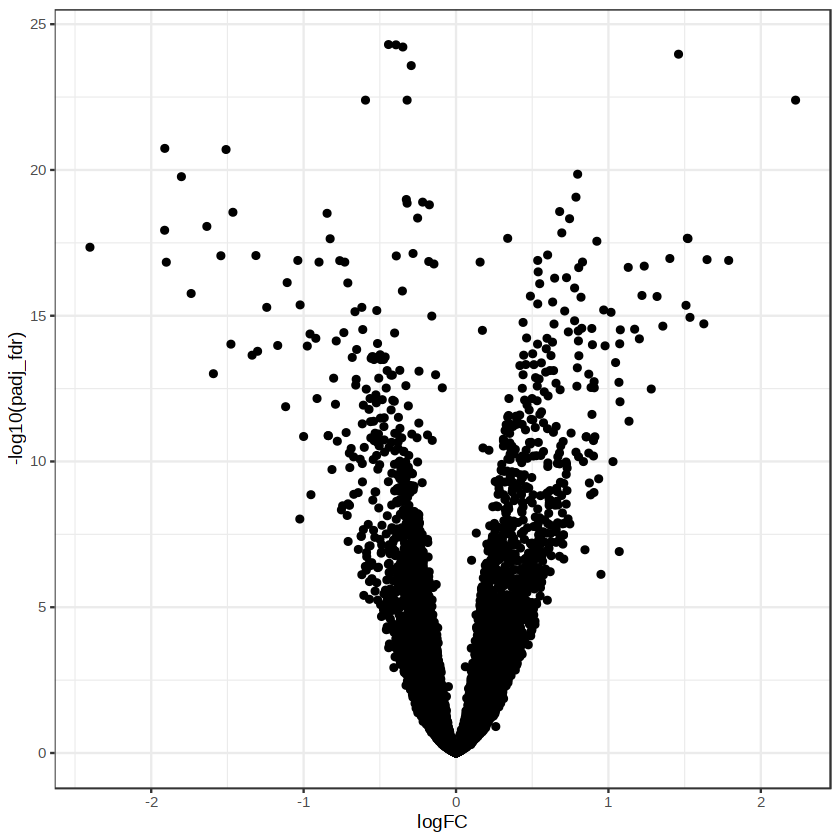

In [15]:
ggplot(DEGs[celltype == 'Early_Mes_EOd'], aes(logFC, -log10(padj_fdr))) + 
    geom_point() +
    theme_bw()

In [11]:
head(DEGs[sig==TRUE][celltype == 'Early_Mes_EOi'][order(-abs(logFC))], 15)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
Etv2,-1.584,4.52e-28,5.93,4.42,0.46,0.24,Early_Mes_EOi,TRUE
Hoxb1,1.431,3.19e-24,4.12,5.53,0.16,0.46,Early_Mes_EOi,TRUE
Magi2,-1.028,9.40e-28,7.87,6.88,0.64,0.49,Early_Mes_EOi,TRUE
Ryr2,-1.016,1.74e-19,6.10,5.14,0.34,0.25,Early_Mes_EOi,TRUE
